# Integrated CellChat Analysis of Colitis Microenvironment Dynamics

#### Rank Aggregation, Median-Rank Analysis, and Regression-Based Interpretation of Cell–Cell Communication Networks Across Colitis Conditions among CAR-T/CAR-TEC Cohorts

**Description**

This notebook performs a comprehensive downstream analysis of CellChat-derived interaction networks in colitis study samples. The workflow includes preprocessing and merging of CellChat outputs, robust-rank aggregation (RRA) and median-rank analyses of ligand–receptor interactions, quality-control assessment, and regression modeling of condition-specific signaling changes. The analysis is designed to identify reproducible intercellular communication programs associated with inflammatory states and engineered immune-cell populations, with emphasis on statistical prioritization, comparative network behavior, and visualization.

In [1]:
# Baseline packages
import pandas as pd
from importlib import reload

from pathlib import Path
import sys
import os
import numpy as np

# Configure source project directory
PROJECT_ROOT = Path.cwd().parent

# Add source directory to path for custom module imports
SRC_DIR = PROJECT_ROOT / "src"
sys.path.append(str(SRC_DIR))

# Custom plotting and analysis script imports
import clutils
import clplots

# Configuration for plotting outputs
import matplotlib as mpl
mpl.rcParams["svg.fonttype"] = "none"
mpl.rcParams["pdf.fonttype"] = 42       
mpl.rcParams["ps.fonttype"] = 42

### Preprocess Data Samples
Compile the raw cellchat files and merge them into a single dataframe for downstream analysis.

In [ ]:
df = clutils.build_cellchat_merged(
    zip_file = os.path.join(PROJECT_ROOT, "data/raw_v4/per_sample_csvs.zip"),
    output_file = os.path.join(PROJECT_ROOT, "data/intermediate_v5/cellchat_merged.parquet"),
    file_pattern = "cellchat_*.csv",
    excluded_populations = ("Mixed", "Proliferating", "Proliferating cells", "Cycling", "Plasma cells", "B cells", "Activated"), # Plasma cells / B cells excluded non-specific
    chemistry_by_sample = None,
    default_chemistry = "unknown",
)

# Clean up condition
chem = pd.read_excel(
    os.path.join(PROJECT_ROOT, "data/raw_v2/CART_metadata.xlsx"), skiprows = 2).set_index("Sample ID").dropna()
chem['Chemistry'] = chem['Chemistry'].replace("3' V3", "3PV3").replace("5' V3", "5PV3")
df['condition'] = df['sample'].map(chem['Condition'].to_dict()).astype(str).astype("category")
df['chemistry'] = df['sample'].map(chem['Chemistry'].to_dict()).astype(str).astype("category")

# Latest samples (not in base metadata file) were all 5' V3 chemistry and CAR-TEC condition
df['chemistry'] = df['chemistry'].fillna("5PV3").replace("nan", "5PV3")
df['condition'] = df['condition'].fillna("CAR-TEC").replace("nan", "CAR-TEC")

# Add celltype counts
meta = pd.read_excel(os.path.join(PROJECT_ROOT, "data/raw_v4/all_celltypes_counts_per_sample_all_labels.xlsx"))
meta = meta.T.loc[~meta.columns.str.endswith("proportion")].T
meta = meta.set_index(["sample_names", "condition"]).drop(columns = ["total_count"])
meta.columns = meta.columns.str.replace("_count", "")
meta = meta.stack().reset_index()
meta = meta.rename(columns = {"level_2" : "celltype", 0 : "count"})

meta["sample_names"] = meta["sample_names"].astype("category")
meta["condition"] = meta["condition"].astype("category")
meta["celltype"] = meta["celltype"].astype("category")
meta["count"] = meta["count"].astype(int)
meta['label'] = meta['sample_names'].astype(str) + "_" + meta['celltype'].astype(str)

# Save those counts out
meta.to_parquet(os.path.join(PROJECT_ROOT, "data/intermediate_v5/celltype_counts.parquet"))

# Add labels for source and target counts
df['label_target'] = df['sample'].astype(str) + "_" + df['target'].astype(str)
df['label_source'] = df['sample'].astype(str) + "_" + df['source'].astype(str)

df['target_count_log'] = np.log(df['label_target'].map(meta.set_index("label")['count'].to_dict()))
df['source_count_log'] = np.log(df['label_source'].map(meta.set_index("label")['count'].to_dict()))

# Save final file out
df.to_parquet(os.path.join(PROJECT_ROOT, "data/intermediate_v5/cellchat_merged.parquet"))

### Quality Control Visualizations
Plot basic quality metric visualizations.

/opt/conda/envs/pysce/lib/python3.8/site-packages/seaborn/matrix.py:1203: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all axes decorations.
  self._figure.tight_layout(**tight_params)


PosixPath('/home/jupyter/sideproject/colitis/results/tables/v6/supplementary_figure_data.xlsx')

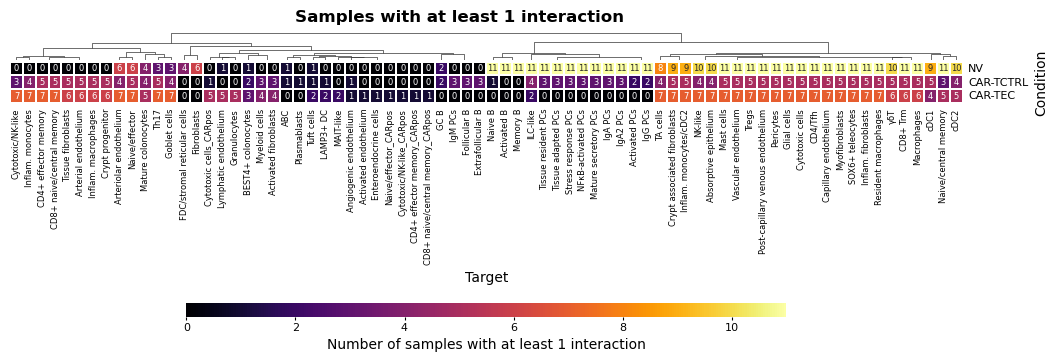

In [4]:
df = pd.read_parquet(os.path.join(PROJECT_ROOT, "data/intermediate_v5/cellchat_merged.parquet"))
df = clutils.filter_by(df, sources = ("T cells", "Endothelial cells"), targets = ("T cells", "Endothelial cells"))
g, mat, count_df = clplots.plot_sample_count_heatmap_qc(
    df,
    value_col="prob",
    condition_col="condition",
    sample_col="sample",
    feature_col="target",
    orientation="horizontal",  # or "vertical"
    annot=True,
    cmap="inferno",
    annot_color=None,
    cbar_span_fraction = 0.5,
    cbar_gap_inches = 2.0,
    figsize = (12, 2.25),
    xticklabel_fontsize = 6.0,
    condition_order=["NV", "CAR-TCTRL", "CAR-TEC"],
)

# Save figure
panel_name = "qc_sample_count_heatmap"
figure_path = os.path.join(PROJECT_ROOT, f"results/figures/v6/{panel_name}.pdf")
g.figure.savefig(figure_path, format="pdf", bbox_inches="tight", transparent=True)

# Save figure panel data
suppfile_path = os.path.join(PROJECT_ROOT, "results/tables/v6/supplementary_figure_data.xlsx")
clutils.write_dataframe_to_excel(count_df, suppfile_path, panel_name)

### Robust Rank Aggregation and Median Rank Analysis of CAR-TEC Samples
We are going to generate a null distribution to develop a permutation based approach of analyzing the rankings across samples.

In [ ]:
# Generate RRA results for CAR-TEC condition
results_rra_tec = clutils.build_robust_rank_aggregation(
    source_file = os.path.join(PROJECT_ROOT, "data/intermediate_v5/cellchat_merged.parquet"),
    output_file = os.path.join(PROJECT_ROOT, "data/intermediate_v5/rra_results_CAR-TEC.parquet"),
    condition = "CAR-TEC",
    show_progress = True
)

plot_rra_scores_publication: loaded 153539 rows
plot_rra_scores_publication: after target filter (2 targets), 5128 rows remain
plot_rra_scores_publication: after rra_fdr < 0.05, 581 rows remain
plot_rra_scores_publication: after top5_freq >= 0.5, 344 rows remain
plot_rra_scores_publication: collapsed sources into 13 grouped labels
plot_rra_scores_publication: after aggregation, 123 grouped rows across 15 unique interactions
plot_rra_scores_publication: after mean_rank_pct >= 90%, 123 grouped rows remain
plot_rra_scores_publication: keeping top 15 unique interactions after ranking
plot_rra_scores_publication: after top_n interaction filter, 123 grouped rows remain
plot_rra_scores_publication: final unique interactions remaining = 15


PosixPath('/home/jupyter/sideproject/colitis/results/tables/v6/supplementary_figure_data.xlsx')

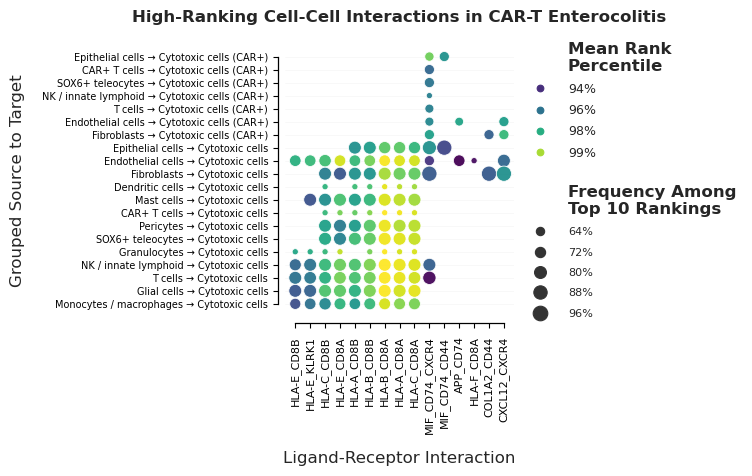

In [5]:
# Plot RRA results for CAR-TEC condition
results_df = pd.read_parquet(os.path.join(PROJECT_ROOT, "data/intermediate_v5/rra_results_CAR-TEC.parquet"))
results_df = clutils.filter_by(results_df, sources = ("T cells", "Endothelial cells"), targets = ("T cells", "Endothelial cells"))
fig, ax, target_df = clplots.plot_rra_scores_publication(
    results = results_df,
    target_values=["Cytotoxic cells", "Cytotoxic cells_CARpos"],
    top_n=40,
    x_axis_mode="source_target",
    source_groups=clplots.DEFAULT_RRA_SOURCE_GROUPS,
    x_axis_label="Ligand-Receptor Interaction",
    y_axis_label="Grouped Source to Target",
    top5_freq_thresh=0.50,
    mean_rank_pct_thresh=0.90,
    figsize = (6,4),
    y_label_wrap_width = 60,
    size_range = (20, 120),
    title="High-Ranking Cell-Cell Interactions in CAR-T Enterocolitis",
    hue_legend_wrap_width=12,
    size_legend_wrap_width=16,
    hue_legend_title_fontsize=12,
    size_legend_title_fontsize=12,
    hue_legend_value_fontsize=9,
    size_legend_value_fontsize=8,
)

# Save figure
panel_name = "rra_top_interactions_CAR"
figure_path = os.path.join(PROJECT_ROOT, f"results/figures/v6/{panel_name}.pdf")
fig.savefig(figure_path, format="pdf", bbox_inches="tight", transparent = True)

# Save figure panel data
suppfile_path = os.path.join(PROJECT_ROOT, "results/tables/v6/supplementary_figure_data.xlsx")
clutils.write_dataframe_to_excel(target_df,suppfile_path, panel_name)

In [ ]:
# Generate MRA results for CAR-TEC condition
results_mra_tec = clutils.run_median_rank_analysis(
    source_file = os.path.join(PROJECT_ROOT, "data/intermediate_v5/cellchat_merged.parquet"),
    output_file = os.path.join(PROJECT_ROOT, "data/intermediate_v5/mra_results_CAR-TEC.parquet"),
    condition="CAR-TEC",
    show_progress=True,
)

PosixPath('/home/jupyter/sideproject/colitis/results/tables/v6/supplementary_figure_data.xlsx')

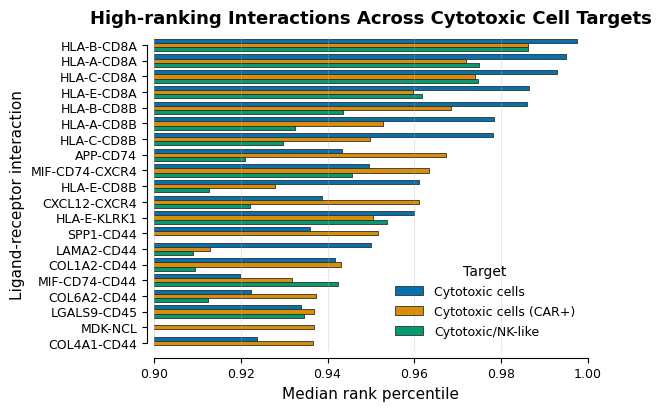

In [6]:
fig, ax, data = clplots.plot_mra_interaction_barplot(
    results="/home/jupyter/sideproject/colitis/data/intermediate_v4/mra_results_CAR-TEC.parquet",
    target_pattern="Cytotox",
    min_rank=0.9,
    top_n=20,
    title="High-ranking Interactions Across Cytotoxic Cell Targets",
    legend_loc="lower right",
    figsize = (6, 4)
)

# Save figure
panel_name = "mra_top_inter_cytotx_CAR-TEC"
figure_path = os.path.join(PROJECT_ROOT, f"results/figures/v6/{panel_name}.pdf")
fig.savefig(figure_path, format="pdf", bbox_inches="tight", transparent = True)

# Save figure panel data
clutils.write_dataframe_to_excel(data,
    os.path.join(PROJECT_ROOT, "results/tables/v6/supplementary_figure_data.xlsx"), panel_name,
)

PosixPath('/home/jupyter/sideproject/colitis/results/tables/v6/supplementary_figure_data.xlsx')

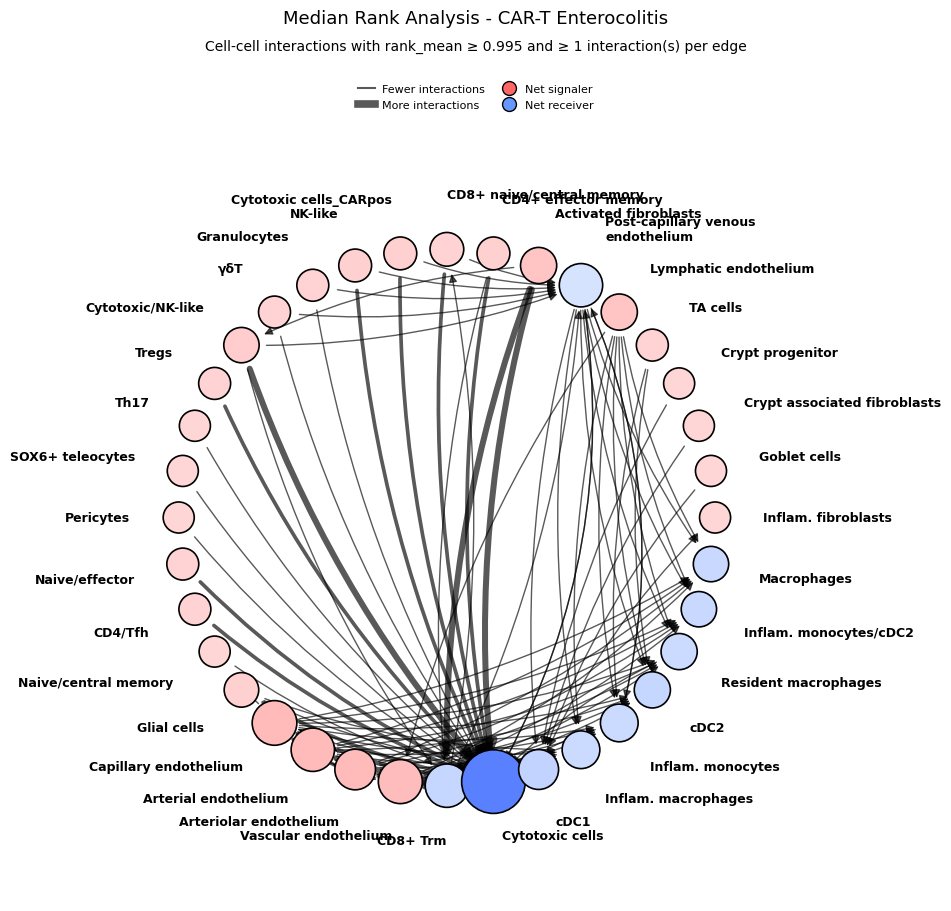

In [7]:
results_mra_car_tec = pd.read_parquet(os.path.join(PROJECT_ROOT, "data/intermediate_v4/mra_results_CAR-TEC.parquet"))
results_mra_car_tec = clutils.filter_by(results_mra_car_tec, sources = ("T cells", "Endothelial cells"), targets = ("T cells", "Endothelial cells"))
fig, ax, data = clplots.plot_interaction_circle_ranks(
    results_mra_car_tec,
    cutoff_rank=0.995,
    rank_col="rank_mean",
    min_n_interactions = 1,
    figsize = (10,10),
    plot_top = 0.85,
    node_radius = 1.0,
    label_wrap_width = 32,
    title = "Median Rank Analysis - CAR-T Enterocolitis",

)

# Save figure
panel_name = "mra_circleplot_CAR-TEC"
figure_path = f"/home/jupyter/sideproject/colitis/results/figures/v6/{panel_name}.pdf"
fig.savefig(figure_path, dpi=300, bbox_inches="tight", format="pdf", transparent=True)

# Save figure panel data
clutils.write_dataframe_to_excel(data,
    os.path.join(PROJECT_ROOT, "results/tables/v6/supplementary_figure_data.xlsx"), panel_name,
)   

### Normal Volunteer (NV) vs. CAR-T Treated Controls (CAR-TCTRL)

In [ ]:
# Load concatenated CellChat data and run regression suite for NV vs CAR-TCTRL comparison
df = pd.read_parquet(os.path.join(PROJECT_ROOT, "data/intermediate_v5/cellchat_merged.parquet"))
regression_suite = clutils.regression.run_default_condition_regression_suite(
    df=df,
    output_dir=os.path.join(PROJECT_ROOT, "data/intermediate_v5/"),
    framework_options={
        "nv_vs_cartctrl": {
            "condition_min_samples": {"NV": 3, "CAR-TCTRL": 3},
            "min_total": 6,
            "output_name": "results_regr_NV_vs_CARTCTRL_pp.parquet",
        },
    },
    verbose=True,
    show_progress=True
)


PosixPath('/home/jupyter/sideproject/colitis/results/tables/v6/supplementary_figure_data.xlsx')

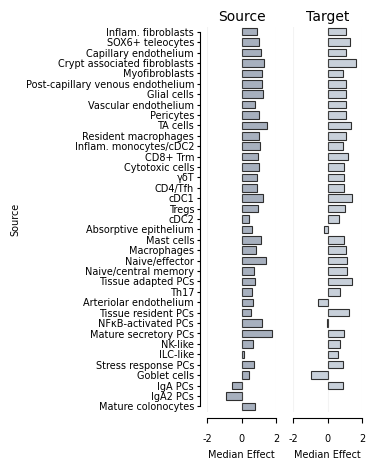

In [8]:
# Reload, summarize
result_regr_ctrl = pd.read_parquet(os.path.join(PROJECT_ROOT, "data/intermediate_v5/results_regr_NV_vs_CARTCTRL_pp.parquet"))
result_regr_ctrl = clutils.filter_by(result_regr_ctrl, sources = ("T cells", "Endothelial cells"), targets = ("T cells", "Endothelial cells"))
summary_stats_regr_ctrl = clutils.summarize_regression_analysis(result_regr_ctrl[result_regr_ctrl.qval_is_treated.lt(0.05)], top_n = 512)

# Export summary results
clutils.export_regression_analysis_summaries_to_excel(
    summary_stats_regr_ctrl,
    os.path.join(PROJECT_ROOT, "results/tables/v6/regression_summary_NV_vs_CARTCTRL.xlsx")
)

# Plot summary barplot
fig, axes, data = clplots.plot_publication_barplot_pair(
    left_df=summary_stats_regr_ctrl['source_summary'],
    right_df=summary_stats_regr_ctrl['target_summary'],
    x_col="median_effect",
    left_y_col="source",
    right_y_col="target",
    figsize=(2, 5),
    left_xlabel="Median Effect",
    right_xlabel="Median Effect",
    y_tick_labelsize=7,
    x_tick_labelsize=7,
    axis_labelsize = 7,
    left_ylabel="Source",
    left_panel_title="Source",
    right_panel_title="Target",
    wspace=0.25,
    left_color="#A7B0BE",
    right_color="#C8D0DA",
)

# Save figure
panel_name = "barplot_summary_ctrl"
figure_path = os.path.join(PROJECT_ROOT, f"results/figures/v6/{panel_name}.pdf")
fig.savefig(figure_path, format="pdf", bbox_inches="tight", transparent = True)

# Save figure panel data
clutils.write_dataframe_to_excel(data['left'],
    os.path.join(PROJECT_ROOT, "results/tables/v6/supplementary_figure_data.xlsx"), panel_name + "_source",
)
clutils.write_dataframe_to_excel(data['right'],
    os.path.join(PROJECT_ROOT, "results/tables/v6/supplementary_figure_data.xlsx"), panel_name + "_target",
)

In [9]:
# Define interactions to highlight for NV vs. CAR-T Control comparison
interaction_specs_ctrl = [
    ("Crypt associated fibroblasts", "Vascular endothelium", "LAMA2_ITGA9_ITGB1"),
    ("Post-capillary venous endothelium", "Resident macrophages", "COL4A2_ITGA9_ITGB1"),
    ("Inflam. fibroblasts", "Cytotoxic cells", "PGE2-PTGES3_PTGER4"),
    ("Cytotoxic cells", "CD8+ Trm", "CLEC2D_KLRB1"),
    ("Post-capillary venous endothelium", "cDC1", "HLA-DRB1_CD4"),
    ("Vascular endothelium", "Cytotoxic cells", "CXCL12_CXCR4"),
    ("Crypt associated fibroblasts", "cDC1", "IGFBP3_TMEM219"),
    ("Absorptive epithelium", "Naive/effector", "NECTIN3_TIGIT"),
    ("Vascular endothelium", "CD4/Tfh", "CXCL12_CXCR4"),
    ("TA cells", "Tissue resident PCs", "TNFSF13_TNFRSF13B"),
    ("SOX6+ teleocytes", "Tissue adapted PCs", "PTN_NCL"),
    ("CD8+ Trm", "TA cells", "GZMA_PARD3"),
    ("CD8+ Trm", "TA cells", "GZMA_F2RL1"),
    ("Cytotoxic cells", "TA cells", "GZMA_PARD3"),
    ("Cytotoxic cells", "TA cells", "CD8A_CEACAM5"),
    ("γδT", "TA cells", "GZMA_PARD3"),
]

PosixPath('/home/jupyter/sideproject/colitis/results/tables/v6/supplementary_figure_data.xlsx')

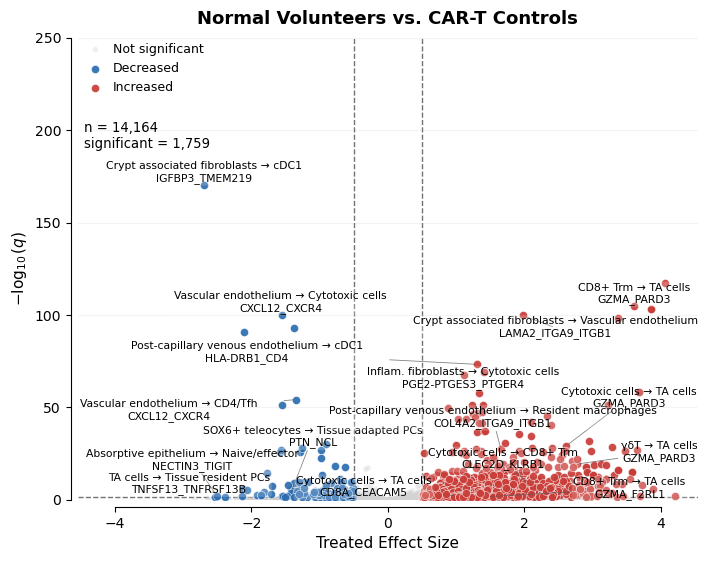

In [10]:
# Reload results files
df = pd.read_parquet(os.path.join(PROJECT_ROOT, "data/intermediate_v5/cellchat_merged.parquet"))
result_regr_ctrl = pd.read_parquet(os.path.join(PROJECT_ROOT, "data/intermediate_v5/results_regr_NV_vs_CARTCTRL_pp.parquet"))
result_regr_ctrl = clutils.filter_by(result_regr_ctrl, sources = ("T cells", "Endothelial cells"), targets = ("T cells", "Endothelial cells"))

# Plot volcano plot for NV vs CAR-T Control regression results, highlighting specified interactions
fig, ax, data = clplots.plot_side_effect_volcano_publication(
    result_regr_ctrl,
    coef_col="coef_is_treated",
    qval_col="qval_is_treated",
    label_col="interaction_name",
    source_col="source",
    target_col="target",
    q_thresh=0.05,
    effect_thresh=0.5,
    top_n=32,
    label_mode="full",
    label_interactions = interaction_specs_ctrl,
    override_auto_labels = True,
    figsize=(8, 6),
    ymax = 250,
    y_break = None,
    title="Normal Volunteers vs. CAR-T Controls",
    xlabel = "Treated Effect Size",
    legend_position="top-left",
)

# Save figure
panel_name = "volcanoplot_nv_vs_ctrl"
figure_path = os.path.join(PROJECT_ROOT, f"results/figures/v6/{panel_name}.pdf")
fig.savefig(figure_path, format="pdf", bbox_inches="tight", transparent = True)

# Save figure panel data
clutils.write_dataframe_to_excel(data,
    os.path.join(PROJECT_ROOT, "results/tables/v6/supplementary_figure_data.xlsx"), panel_name,
)

PosixPath('/home/jupyter/sideproject/colitis/results/tables/v6/supplementary_figure_data.xlsx')

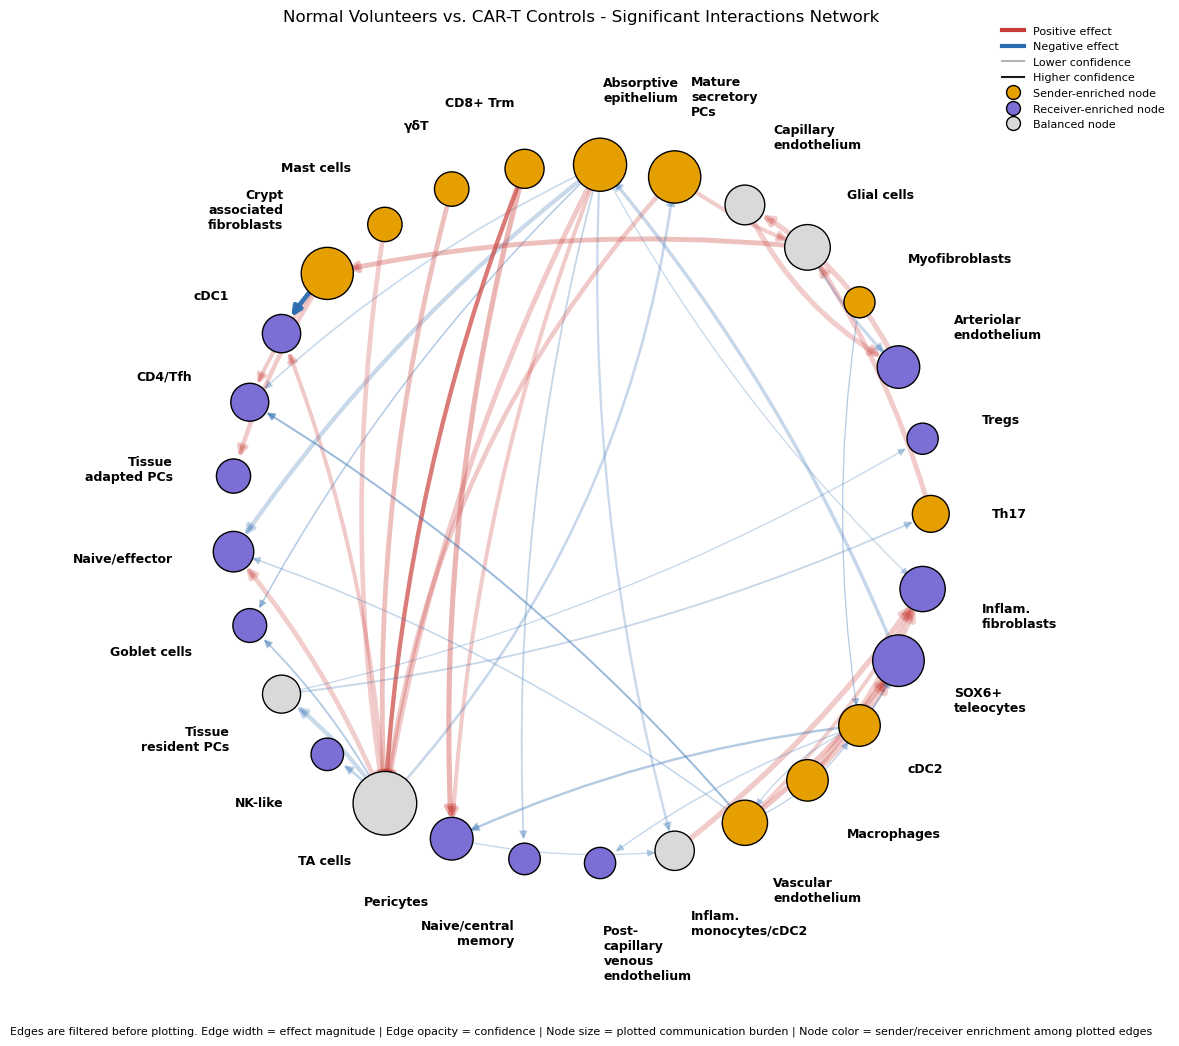

In [11]:
# Reload results
result_regr_ctrl = pd.read_parquet(os.path.join(PROJECT_ROOT, "data/intermediate_v5/results_regr_NV_vs_CARTCTRL_pp.parquet"))
result_regr_ctrl = clutils.filter_by(result_regr_ctrl, sources = ("T cells", "Endothelial cells"), targets = ("T cells", "Endothelial cells"))

fig, ax, agg_edges, data = clplots.plot_celltype_circle_network_publication_updated(
    result_regr_ctrl,
    source_col="source",
    target_col="target",
    coef_col="coef_is_treated",
    qval_col="qval_is_treated",
    q_thresh=0.05,
    agg="mean",
    min_abs_coef=0.5,
    min_interactions_per_edge=1,
    top_n_edges=48,
    balance_directions=True,
    node_size_mode="strength",
    label_outside=True,
    figsize=(12, 12),
    title="Normal Volunteers vs. CAR-T Controls - Significant Interactions Network",
)

# Save figure
panel_name = "circleplot_nv_vs_ctrl"
figure_path = os.path.join(PROJECT_ROOT, f"results/figures/v6/{panel_name}.pdf")
fig.savefig(figure_path, format="pdf", bbox_inches="tight", transparent = True)

# Save figure panel data
clutils.write_dataframe_to_excel(data,
    os.path.join(PROJECT_ROOT, "results/tables/v6/supplementary_figure_data.xlsx"), panel_name,
)

PosixPath('/home/jupyter/sideproject/colitis/results/tables/v6/supplementary_figure_data.xlsx')

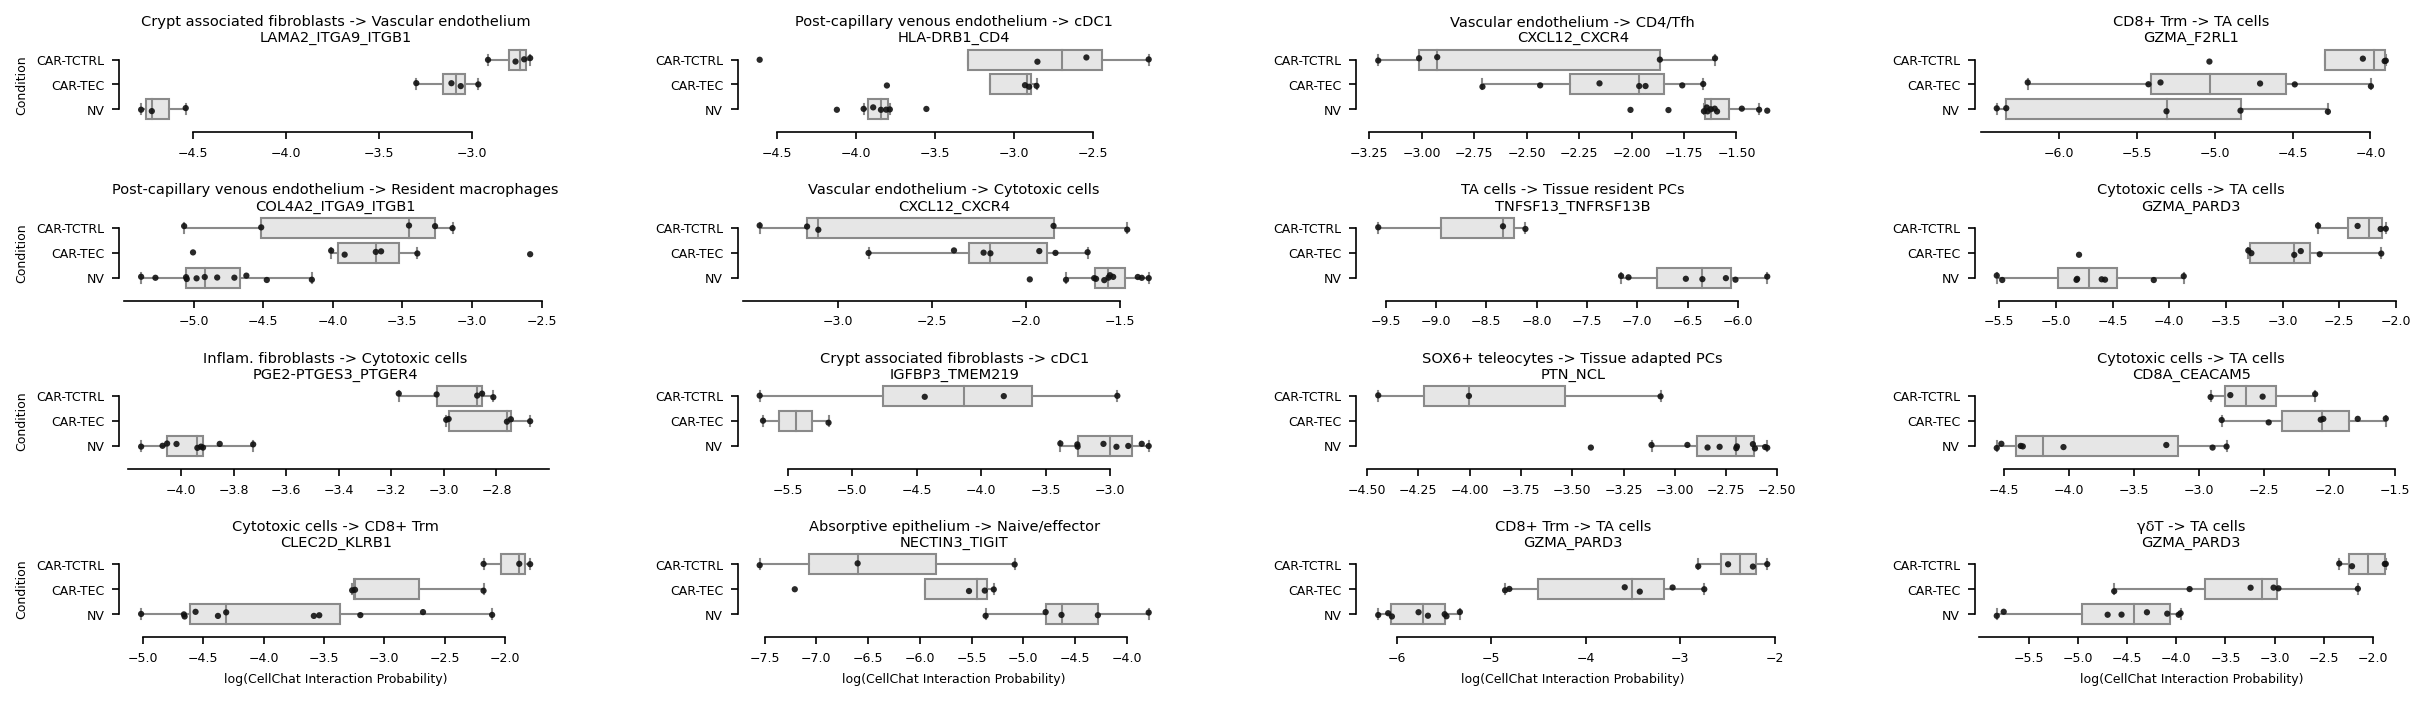

In [12]:
# Reload results files
df = pd.read_parquet(os.path.join(PROJECT_ROOT, "data/intermediate_v5/cellchat_merged.parquet"))
result_regr_ctrl = pd.read_parquet(os.path.join(PROJECT_ROOT, "data/intermediate_v5/results_regr_NV_vs_CARTCTRL_pp.parquet"))
result_regr_ctrl = clutils.filter_by(result_regr_ctrl, sources = ("T cells", "Endothelial cells"), targets = ("T cells", "Endothelial cells"))

# Plot
fig, axes, data = clplots.plot_interaction_logprob_qc_stack(
    results=df,
    interactions=interaction_specs_ctrl,
    max_stack=4,
    panel_figsize=(4.5, 1.15),
    dpi=150,
    font_size=6,
    hspace = 1.25,
    wspace = 0.5,
)

# Save figure
panel_name = "boxplots_nv_vs_ctrl"
figure_path = os.path.join(PROJECT_ROOT, f"results/figures/v6/{panel_name}.pdf")
fig.savefig(figure_path, format="pdf", bbox_inches="tight", transparent = True)

# Save figure panel data
clutils.write_dataframe_to_excel(data,
    os.path.join(PROJECT_ROOT, "results/tables/v6/supplementary_figure_data.xlsx"), panel_name,
)

### CAR-T Treated Controls (CAR-TCTRL) vs. CAR-T Enterocolitis (CAR-TEC)

In [ ]:
# Load concatenated CellChat data and run regression suite for CAR-TCTRL vs CAR-TEC comparison
df = pd.read_parquet(os.path.join(PROJECT_ROOT, "data/intermediate_v5/cellchat_merged.parquet"))
regression_suite = clutils.regression.run_default_condition_regression_suite(
    df=df,
    output_dir=os.path.join(PROJECT_ROOT, "data/intermediate_v5/"),
    framework_options={
        "cartctrl_vs_cartec": {
            "condition_min_samples": {"CAR-TCTRL": 3, "CAR-TEC": 3},
            "min_total": 6,
            "output_name": "results_regr_CARTCTRL_vs_CARTEC_pp.parquet",
        },
    },
    verbose=True,
    show_progress=True
)

PosixPath('/home/jupyter/sideproject/colitis/results/tables/v6/supplementary_figure_data.xlsx')

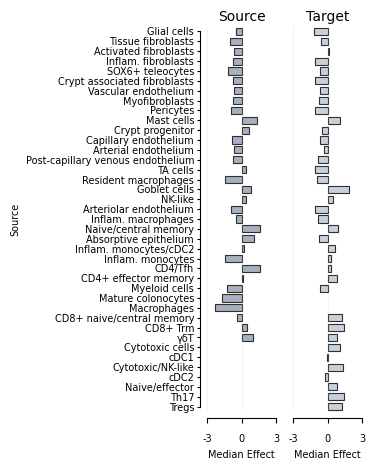

In [13]:
# Reload, summarize
result_regr_tec = pd.read_parquet(os.path.join(PROJECT_ROOT, "data/intermediate_v5/results_regr_CARTCTRL_vs_CARTEC_pp.parquet"))
result_regr_tec = clutils.filter_by(result_regr_tec, sources = ("T cells", "Endothelial cells"), targets = ("T cells", "Endothelial cells"))

summary_stats_regr_tec = clutils.summarize_regression_analysis(
    result_regr_tec[result_regr_tec.qval_has_colitis.lt(0.05)], 
    coef_col = "coef_has_colitis",
    p_col = "pval_has_colitis",
    q_col = "qval_has_colitis",
    positive_label = "CAR-TEC",
    top_n = 512)

# Export summary results
clutils.export_regression_analysis_summaries_to_excel(
    summary_stats_regr_tec,
    os.path.join(PROJECT_ROOT, "results/tables/v6/regression_summary_CARTCTRL_vs_CARTEC.xlsx")
)

# Plot summary barplot
fig, axes, data = clplots.plot_publication_barplot_pair(
    left_df=summary_stats_regr_tec['source_summary'],
    right_df=summary_stats_regr_tec['target_summary'],
    x_col="median_effect",
    left_y_col="source",
    right_y_col="target",
    figsize=(2, 5),
    left_xlabel="Median Effect",
    right_xlabel="Median Effect",
    y_tick_labelsize=7,
    x_tick_labelsize=7,
    axis_labelsize = 7,
    left_ylabel="Source",
    left_panel_title="Source",
    right_panel_title="Target",
    wspace=0.25,
    left_color="#A7B0BE",
    right_color="#C8D0DA",
)

# Save figure
panel_name = "barplot_summary_tec"
figure_path = os.path.join(PROJECT_ROOT, f"results/figures/v6/{panel_name}.pdf")
fig.savefig(figure_path, format="pdf", bbox_inches="tight", transparent = True)

# Save figure panel data
clutils.write_dataframe_to_excel(data['left'],
    os.path.join(PROJECT_ROOT, "results/tables/v6/supplementary_figure_data.xlsx"), panel_name + "_source",
)
clutils.write_dataframe_to_excel(data['right'],
    os.path.join(PROJECT_ROOT, "results/tables/v6/supplementary_figure_data.xlsx"), panel_name + "_target",
)

In [14]:
# Define interactions to highlight for CAR-T Control and CAR-T Enterocolitis comparison
interaction_specs_tec = [
    ("Pericytes", "TA cells", "LAMB1_ITGA2_ITGB1"),
    ("Pericytes", "Inflam. monocytes", "COL6A3_SDC4"),
    ("SOX6+ teleocytes", "Resident macrophages", "IGFBP3_TMEM219"),
    ("SOX6+ teleocytes", "TA cells", "IGFBP3_TMEM219"),
    ("SOX6+ teleocytes", "Vascular endothelium", "IGFBP3_TMEM219"),
    ("Mast cells", "Cytotoxic cells", "HLA-F_CD8A"),
    ("Glial cells", "Th17", "MDK_ITGA4_ITGB1"),
    ("Glial cells", "cDC1", "MDK_ITGA4_ITGB1"),
    ("Mast cells", "Resident macrophages", "HLA-F_LILRB1"),
    ("Mast cells", "CD8+ Trm", "HLA-F_CD8A"),
    ("Mast cells", "CD8+ naive/central memory", "HLA-F_CD8A"),
    ("Glial cells", "Tregs", "MDK_ITGA4_ITGB1"),
    ("Glial cells", "Cytotoxic cells", "HLA-F_CD8A"),
    ("Glial cells", "CD8+ Trm", "MDK_NCL"),
    ("Crypt progenitor", "Crypt progenitor", "Cholesterol-Cholesterol-DHCR24_RORC"),
    ("Crypt progenitor", "Naive/central memory", "PGE2-PTGES2_PTGER4"),
    ("Crypt progenitor", "Inflam. monocytes/cDC2", "TNFSF10_TNFRSF10B"),
    ("SOX6+ teleocytes", "Crypt progenitor", "IGFBP3_TMEM219"),
    ("Mature colonocytes", "Crypt progenitor", "GUCA2B_GUCY2C"),
]

PosixPath('/home/jupyter/sideproject/colitis/results/tables/v6/supplementary_figure_data.xlsx')

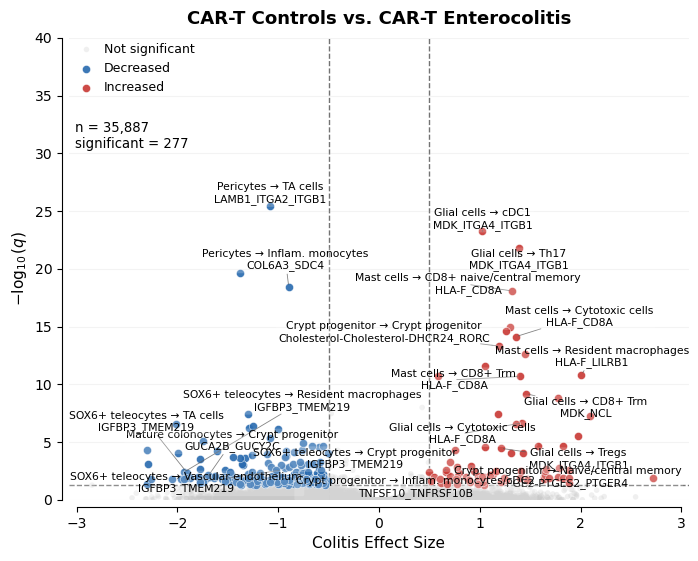

In [15]:
# Reload results files
df = pd.read_parquet(os.path.join(PROJECT_ROOT, "data/intermediate_v5/cellchat_merged.parquet"))
result_regr_tec = pd.read_parquet(os.path.join(PROJECT_ROOT, "data/intermediate_v5/results_regr_CARTCTRL_vs_CARTEC_pp.parquet"))
result_regr_tec = clutils.filter_by(result_regr_tec, sources = ("T cells", "Endothelial cells"), targets = ("T cells", "Endothelial cells"))

# Plot volcano plot for CAR-T Control vs CAR-T Enterocolitis regression results, highlighting specified interactions
fig, ax, data = clplots.plot_side_effect_volcano_publication(
    result_regr_tec,
    coef_col="coef_has_colitis",
    qval_col="qval_has_colitis",
    label_col="interaction_name",
    source_col="source",
    target_col="target",
    q_thresh=0.05,
    effect_thresh=0.5,
    top_n=32,
    label_mode="full",
    label_interactions = interaction_specs_tec,
    override_auto_labels = True,
    figsize=(8, 6),
    ymax = 40,
    y_break = None,
    title="CAR-T Controls vs. CAR-T Enterocolitis",
    xlabel = "Colitis Effect Size",
    legend_position="top-left",
)

# Save figure
panel_name = "volcanoplot_ctrl_vs_tec"
figure_path = os.path.join(PROJECT_ROOT, f"results/figures/v6/{panel_name}.pdf")
fig.savefig(figure_path, format="pdf", bbox_inches="tight", transparent = True)

# Save figure panel data
clutils.write_dataframe_to_excel(data,
    os.path.join(PROJECT_ROOT, "results/tables/v6/supplementary_figure_data.xlsx"), panel_name,
)

PosixPath('/home/jupyter/sideproject/colitis/results/tables/v6/supplementary_figure_data.xlsx')

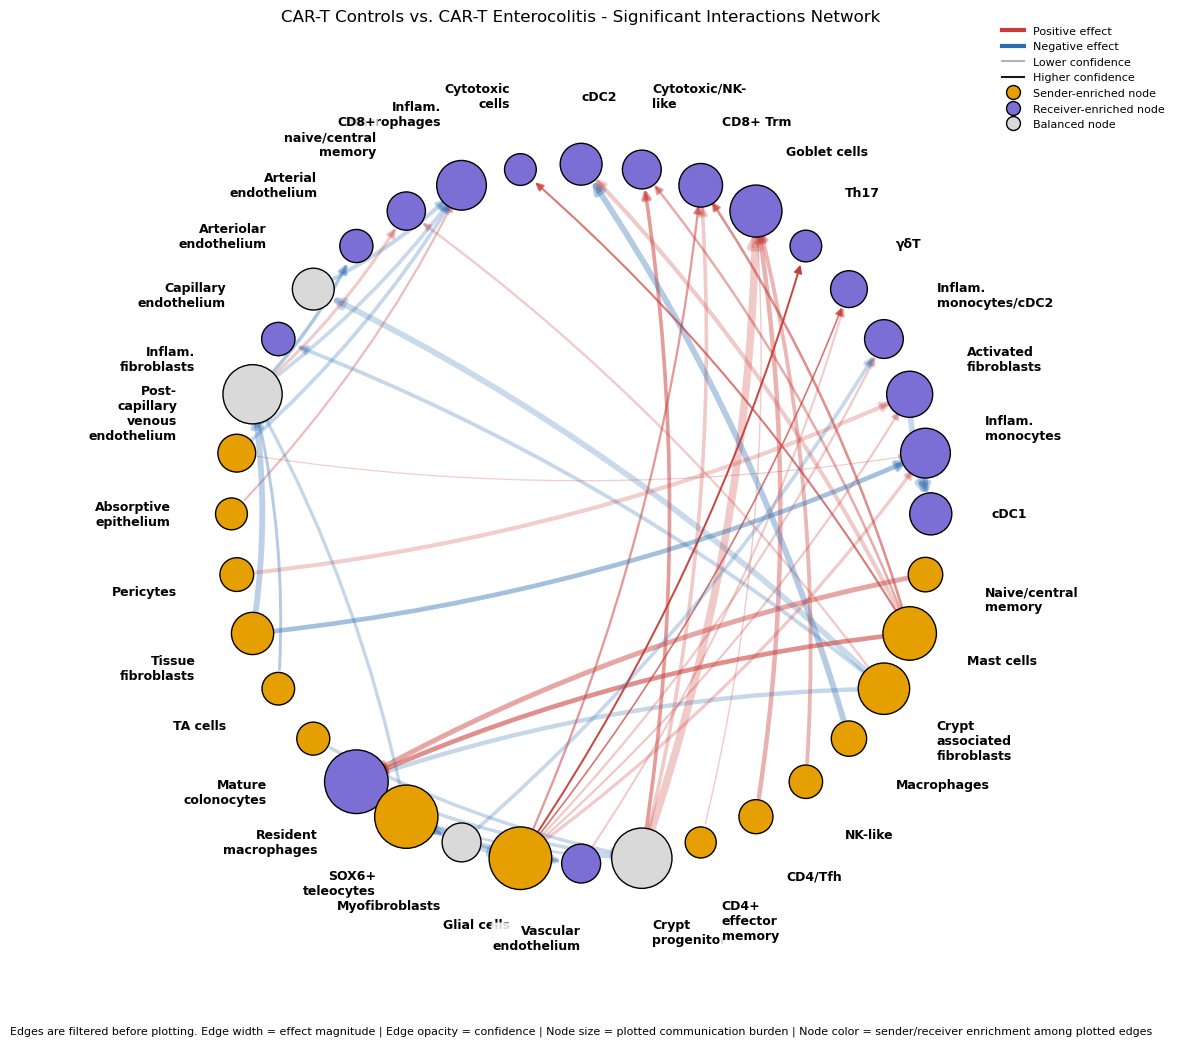

In [16]:
# Reload results
result_regr_tec = pd.read_parquet(os.path.join(PROJECT_ROOT, "data/intermediate_v5/results_regr_CARTCTRL_vs_CARTEC_pp.parquet"))
result_regr_tec = clutils.filter_by(result_regr_tec, sources = ("T cells", "Endothelial cells"), targets = ("T cells", "Endothelial cells"))

fig, ax, agg_edges, data = clplots.plot_celltype_circle_network_publication_updated(
    result_regr_tec,
    source_col="source",
    target_col="target",
    coef_col="coef_has_colitis",      # keep this if that's your actual dataframe column
    qval_col="qval_has_colitis",
    q_thresh=0.05,
    agg="mean",
    min_abs_coef=0.5,
    min_interactions_per_edge=1,
    top_n_edges=48,
    balance_directions=True,
    node_size_mode="strength",
    label_outside=True,
    figsize=(12, 12),
    title="CAR-T Controls vs. CAR-T Enterocolitis - Significant Interactions Network",
)

# Save figure
panel_name = "circleplot_ctrl_vs_tec"
figure_path = os.path.join(PROJECT_ROOT, f"results/figures/v6/{panel_name}.pdf")
fig.savefig(figure_path, format="pdf", bbox_inches="tight", transparent = True)

# Save figure panel data
clutils.write_dataframe_to_excel(data,
    os.path.join(PROJECT_ROOT, "results/tables/v6/supplementary_figure_data.xlsx"), panel_name,
)

PosixPath('/home/jupyter/sideproject/colitis/results/tables/v6/supplementary_figure_data.xlsx')

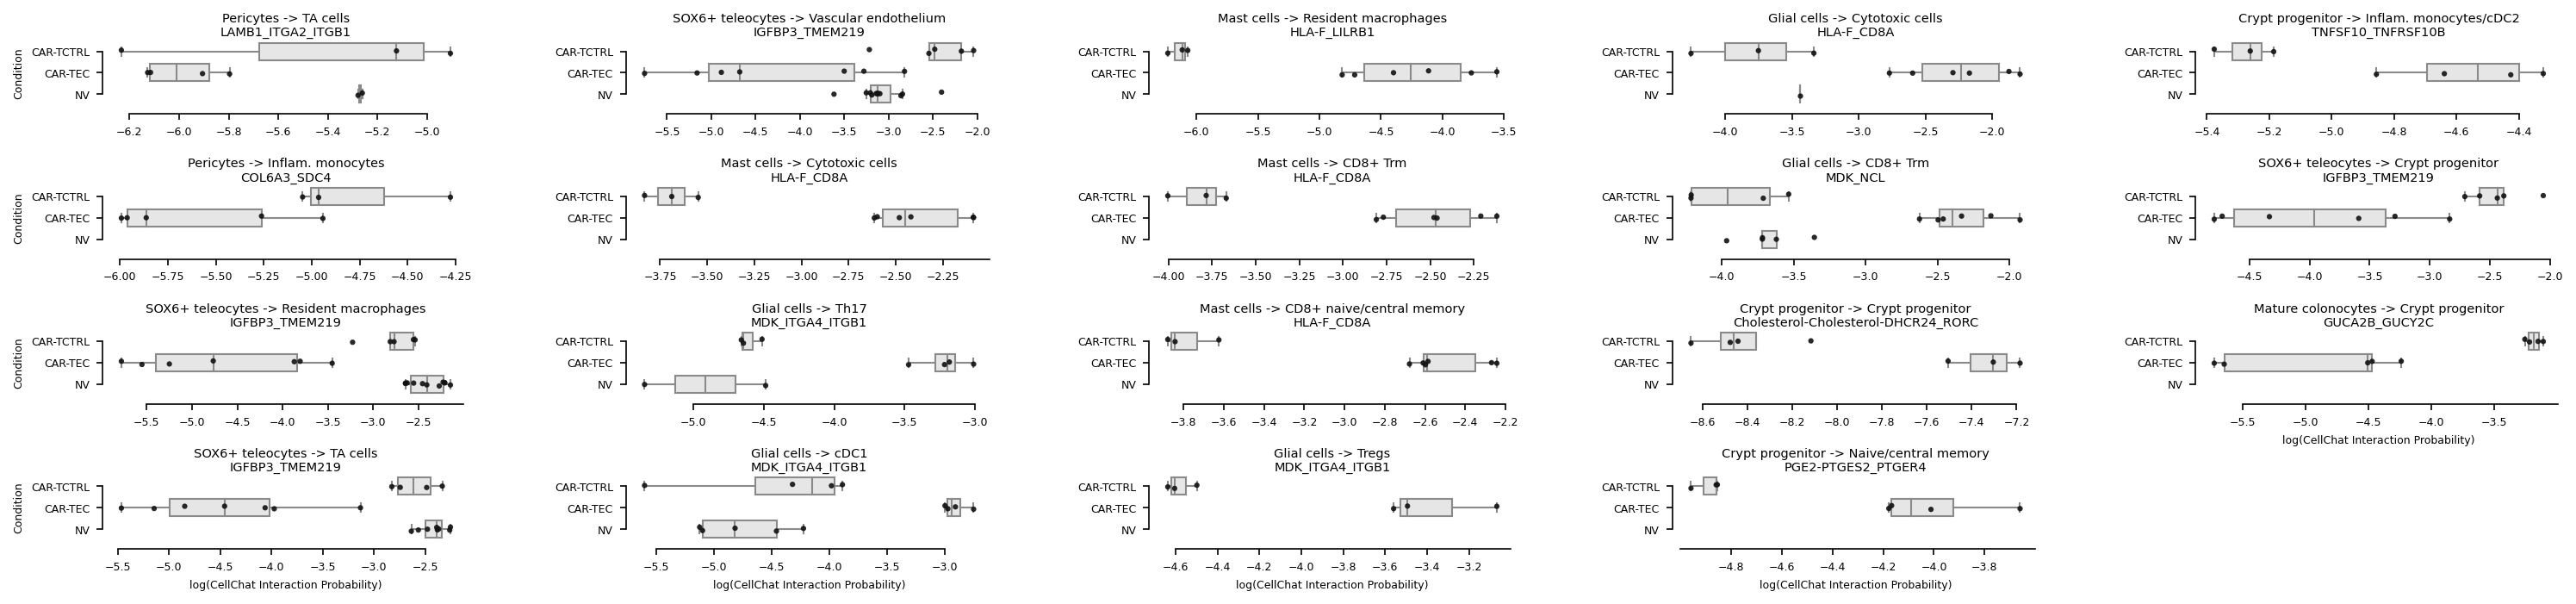

In [17]:
# Reload results files
df = pd.read_parquet(os.path.join(PROJECT_ROOT, "data/intermediate_v5/cellchat_merged.parquet"))
result_regr_tec = pd.read_parquet(os.path.join(PROJECT_ROOT, "data/intermediate_v5/results_regr_CARTCTRL_vs_CARTEC_pp.parquet"))
result_regr_tec = clutils.filter_by(result_regr_tec, sources = ("T cells", "Endothelial cells"), targets = ("T cells", "Endothelial cells"))

# Plot
fig, axes, data = clplots.plot_interaction_logprob_qc_stack(
    results=df,
    interactions=interaction_specs_tec,
    max_stack=4,
    panel_figsize=(4.5, 1.15),
    dpi=150,
    font_size=6,
    hspace = 1.25,
    wspace = 0.5,
)

# Save figure
panel_name = "boxplots_ctrl_vs_tec"
figure_path = os.path.join(PROJECT_ROOT, f"results/figures/v6/{panel_name}.pdf")
fig.savefig(figure_path, format="pdf", bbox_inches="tight", transparent = True)

# Save figure panel data
clutils.write_dataframe_to_excel(data,
    os.path.join(PROJECT_ROOT, "results/tables/v6/supplementary_figure_data.xlsx"), panel_name,
)

### Normal Volunteer (NV) vs. CAR-T Enterocolitis (CAR-TEC)

In [ ]:
# Load concatenated CellChat data and run regression suite for NV vs CAR-TEC comparison
df = pd.read_parquet(os.path.join(PROJECT_ROOT, "data/intermediate_v5/cellchat_merged.parquet"))
regression_suite = clutils.regression.run_default_condition_regression_suite(
    df=df,
    output_dir=os.path.join(PROJECT_ROOT, "data/intermediate_v5/"),
    framework_options={
        "nv_vs_cartec": {
            "condition_min_samples": {"NV": 3, "CAR-TEC": 3},
            "min_total": 6,
            "output_name": "results_regr_NV_vs_CARTEC_pp.parquet",
        },
    },
    verbose=True,
    show_progress=True
)

PosixPath('/home/jupyter/sideproject/colitis/results/tables/v6/supplementary_figure_data.xlsx')

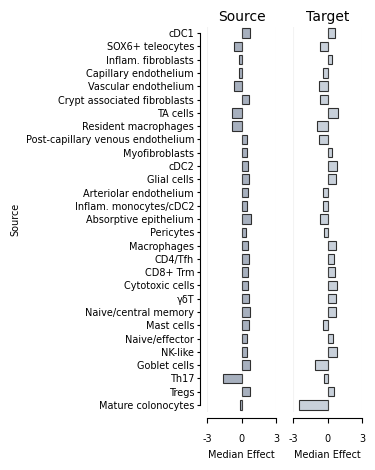

In [18]:
# Reload, summarize
result_regr_nv_vs_cartec = pd.read_parquet(os.path.join(PROJECT_ROOT, "data/intermediate_v5/results_regr_NV_vs_CARTEC_pp.parquet"))
result_regr_nv_vs_cartec = clutils.filter_by(result_regr_nv_vs_cartec, sources = ("T cells", "Endothelial cells"), targets = ("T cells", "Endothelial cells"))

summary_stats_regr_nv_vs_cartec = clutils.summarize_regression_analysis(
    result_regr_nv_vs_cartec[result_regr_nv_vs_cartec.qval_is_treated.lt(0.05)], 
    positive_label = "CAR-TEC",
    top_n = 512)

# Export summary results
clutils.export_regression_analysis_summaries_to_excel(
    summary_stats_regr_nv_vs_cartec,
    os.path.join(PROJECT_ROOT, "results/tables/v6/regression_summary_NV_vs_CARTEC.xlsx")
)

# Plot summary barplot
fig, axes, data = clplots.plot_publication_barplot_pair(
    left_df=summary_stats_regr_nv_vs_cartec['source_summary'],
    right_df=summary_stats_regr_nv_vs_cartec['target_summary'],
    x_col="median_effect",
    left_y_col="source",
    right_y_col="target",
    figsize=(2, 5),
    left_xlabel="Median Effect",
    right_xlabel="Median Effect",
    y_tick_labelsize=7,
    x_tick_labelsize=7,
    axis_labelsize = 7,
    left_ylabel="Source",
    left_panel_title="Source",
    right_panel_title="Target",
    wspace=0.25,
    left_color="#A7B0BE",
    right_color="#C8D0DA",
)

# Save figure
panel_name = "barplot_summary_nv_v_tec"
figure_path = os.path.join(PROJECT_ROOT, f"results/figures/v6/{panel_name}.pdf")
fig.savefig(figure_path, format="pdf", bbox_inches="tight", transparent = True)

# Save figure panel data
clutils.write_dataframe_to_excel(data['left'],
    os.path.join(PROJECT_ROOT, "results/tables/v6/supplementary_figure_data.xlsx"), panel_name + "_source",
)
clutils.write_dataframe_to_excel(data['right'],
    os.path.join(PROJECT_ROOT, "results/tables/v6/supplementary_figure_data.xlsx"), panel_name + "_target",
)

In [20]:
interaction_specs_nv_vs_cartec = [
    ("Inflam. monocytes/cDC2", "cDC1", "LGALS9_CD45"),
    ("Glial cells", "cDC1", "MDK_NCL"),
    ("cDC1", "cDC1", "HLA-DOA_CD4"),
    ("cDC2", "Cytotoxic cells", "HLA-F_CD8B"),
    ("cDC2", "Cytotoxic cells", "HLA-A_CD8B"),
    ("cDC1", "Cytotoxic cells", "PGE2-PTGES2_PTGER4"),
    ("SOX6+ teleocytes", "Myofibroblasts", "PTN_NCL"),
    ("SOX6+ teleocytes", "Resident macrophages", "PTN_NCL"),
    ("SOX6+ teleocytes", "Resident macrophages", "IGFBP3_TMEM219"),
    ("Crypt associated fibroblasts", "TA cells", "LAMC1_CD44"),
    ("Pericytes", "TA cells", "APP_CD74"),
    ("SOX6+ teleocytes", "TA cells", "IGFBP3_TMEM219"),
    ("Inflam. fibroblasts", "Tregs", "MIF_CD74_CXCR4"),
    ("Cytotoxic cells", "NK-like", "MIF_CD74_CXCR4"),
    ("Arteriolar endothelium", "Tregs", "APP_CD74"),
]

PosixPath('/home/jupyter/sideproject/colitis/results/tables/v6/supplementary_figure_data.xlsx')

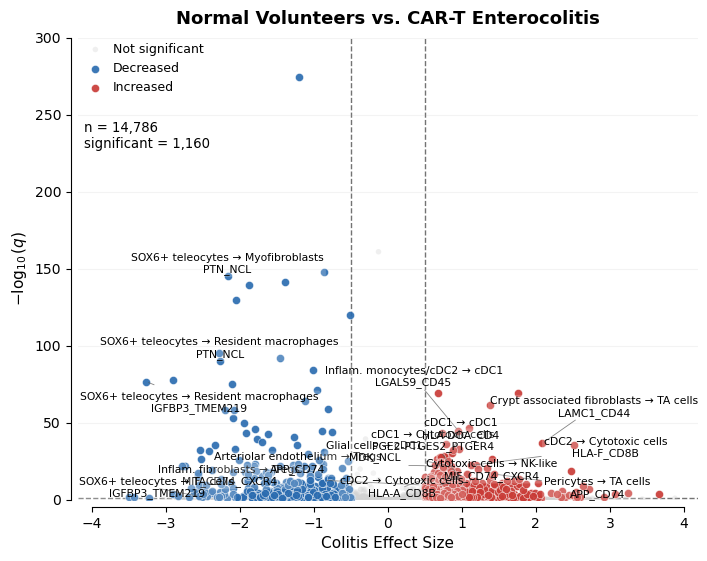

In [21]:
# Reload results files
df = pd.read_parquet(os.path.join(PROJECT_ROOT, "data/intermediate_v5/cellchat_merged.parquet"))
result_regr_nv_vs_cartec = pd.read_parquet(os.path.join(PROJECT_ROOT, "data/intermediate_v5/results_regr_NV_vs_CARTEC_pp.parquet"))
result_regr_nv_vs_cartec = clutils.filter_by(result_regr_nv_vs_cartec, sources = ("T cells", "Endothelial cells"), targets = ("T cells", "Endothelial cells"))

# Plot volcano plot for CAR-T Control vs CAR-T Enterocolitis regression results, highlighting specified interactions
fig, ax, data = clplots.plot_side_effect_volcano_publication(
    result_regr_nv_vs_cartec,
    coef_col="coef_is_treated",
    qval_col="qval_is_treated",
    label_col="interaction_name",
    source_col="source",
    target_col="target",
    q_thresh=0.05,
    effect_thresh=0.5,
    top_n=8,
    label_interactions = interaction_specs_nv_vs_cartec,
    override_auto_labels = True,
    label_mode="full",
    figsize=(8, 6),
    ymax = 300,
    y_break = None,
    title="Normal Volunteers vs. CAR-T Enterocolitis",
    xlabel = "Colitis Effect Size",
    legend_position="top-left",
)

# Save figure
panel_name = "volcanoplot_nv_v_tec"
figure_path = os.path.join(PROJECT_ROOT, f"results/figures/v6/{panel_name}.pdf")
fig.savefig(figure_path, format="pdf", bbox_inches="tight", transparent = True)

# Save figure panel data
clutils.write_dataframe_to_excel(data,
    os.path.join(PROJECT_ROOT, "results/tables/v6/supplementary_figure_data.xlsx"), panel_name,
)

PosixPath('/home/jupyter/sideproject/colitis/results/tables/v6/supplementary_figure_data.xlsx')

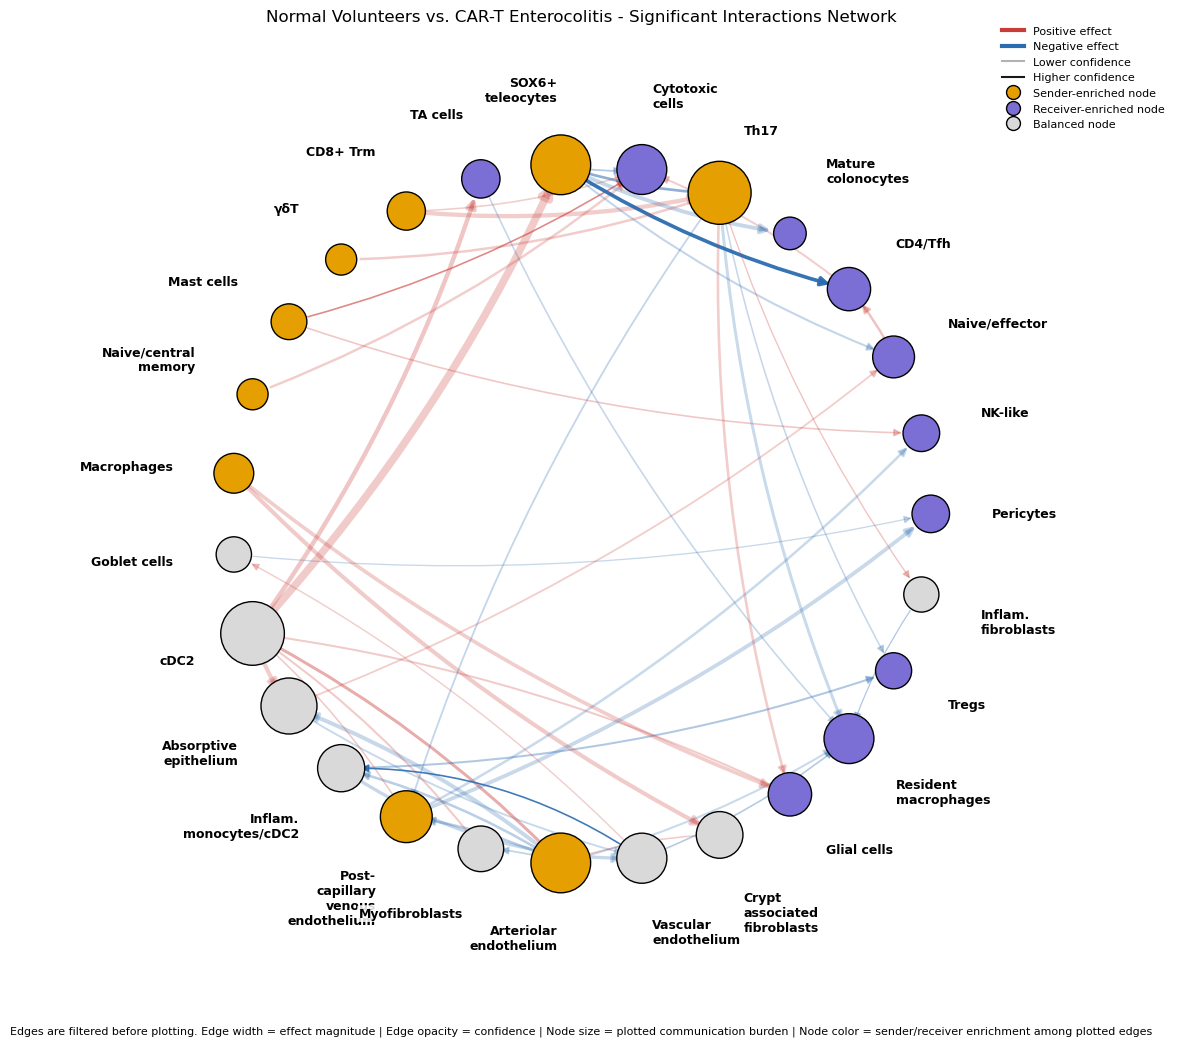

In [22]:
# Reload results
result_regr_nv_vs_cartec = pd.read_parquet(os.path.join(PROJECT_ROOT, "data/intermediate_v5/results_regr_NV_vs_CARTEC_pp.parquet"))
result_regr_nv_vs_cartec = clutils.filter_by(result_regr_nv_vs_cartec, sources = ("T cells", "Endothelial cells"), targets = ("T cells", "Endothelial cells"))

fig, ax, agg_edges, data = clplots.plot_celltype_circle_network_publication_updated(
    result_regr_nv_vs_cartec,
    source_col="source",
    target_col="target",
    coef_col="coef_is_treated",
    qval_col="qval_is_treated",
    q_thresh=0.05,
    agg="mean",
    min_abs_coef=0.5,
    min_interactions_per_edge=1,
    top_n_edges=48,
    balance_directions=True,
    node_size_mode="strength",
    label_outside=True,
    figsize=(12, 12),
    title="Normal Volunteers vs. CAR-T Enterocolitis - Significant Interactions Network",
)

# Save figure
panel_name = "circleplot_nv_v_tec"
figure_path = os.path.join(PROJECT_ROOT, f"results/figures/v6/{panel_name}.pdf")
fig.savefig(figure_path, format="pdf", bbox_inches="tight", transparent = True)

# Save figure panel data
clutils.write_dataframe_to_excel(data,
    os.path.join(PROJECT_ROOT, "results/tables/v6/supplementary_figure_data.xlsx"), panel_name,
)

PosixPath('/home/jupyter/sideproject/colitis/results/tables/v6/supplementary_figure_data.xlsx')

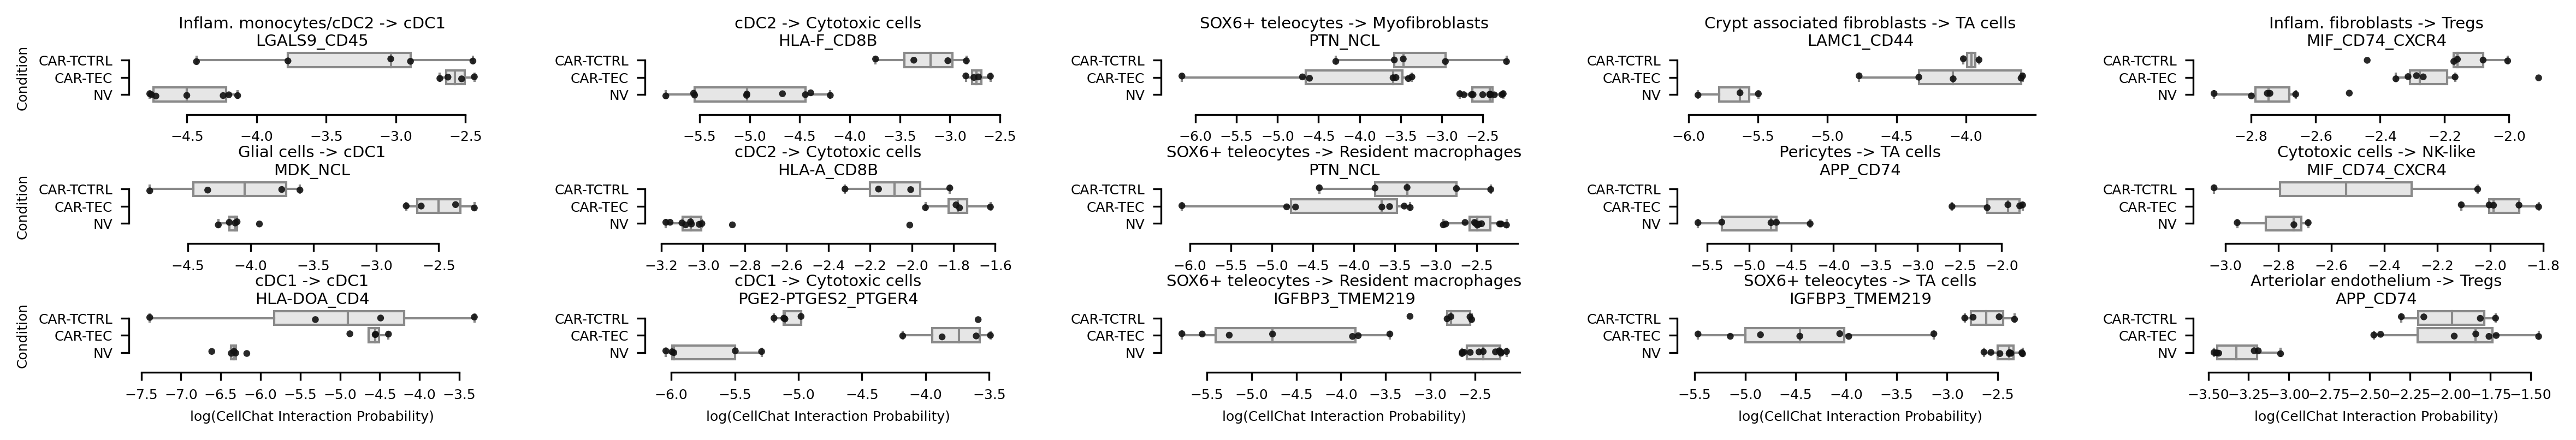

In [23]:
# Reload results files
df = pd.read_parquet(os.path.join(PROJECT_ROOT, "data/intermediate_v5/cellchat_merged.parquet"))
result_regr_nv_vs_cartec = pd.read_parquet(os.path.join(PROJECT_ROOT, "data/intermediate_v5/results_regr_NV_vs_CARTEC_pp.parquet"))
result_regr_nv_vs_cartec = clutils.filter_by(result_regr_nv_vs_cartec, sources = ("T cells", "Endothelial cells"), targets = ("T cells", "Endothelial cells"))

# Plot
fig, axes, data = clplots.plot_interaction_logprob_qc_stack(
    results=df,
    interactions=interaction_specs_nv_vs_cartec,
    max_stack=3,
    panel_figsize=(3.5, 0.75),
    dpi=300,
    font_size=6,
    hspace = 1.5,
    wspace = 0.5,
)

# Save figure
panel_name = "boxplots_nv_v_tec"
figure_path = os.path.join(PROJECT_ROOT, f"results/figures/v6/{panel_name}.pdf")
fig.savefig(figure_path, format="pdf", bbox_inches="tight", transparent = True)

# Save figure panel data
clutils.write_dataframe_to_excel(data,
    os.path.join(PROJECT_ROOT, "results/tables/v6/supplementary_figure_data.xlsx"), panel_name,
)